/tmp/ipykernel_1113/2332039286.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([t.split('.')[0] for t in tickers], rotation=0, fontweight='bold')
/tmp/ipykernel_1113/2332039286.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


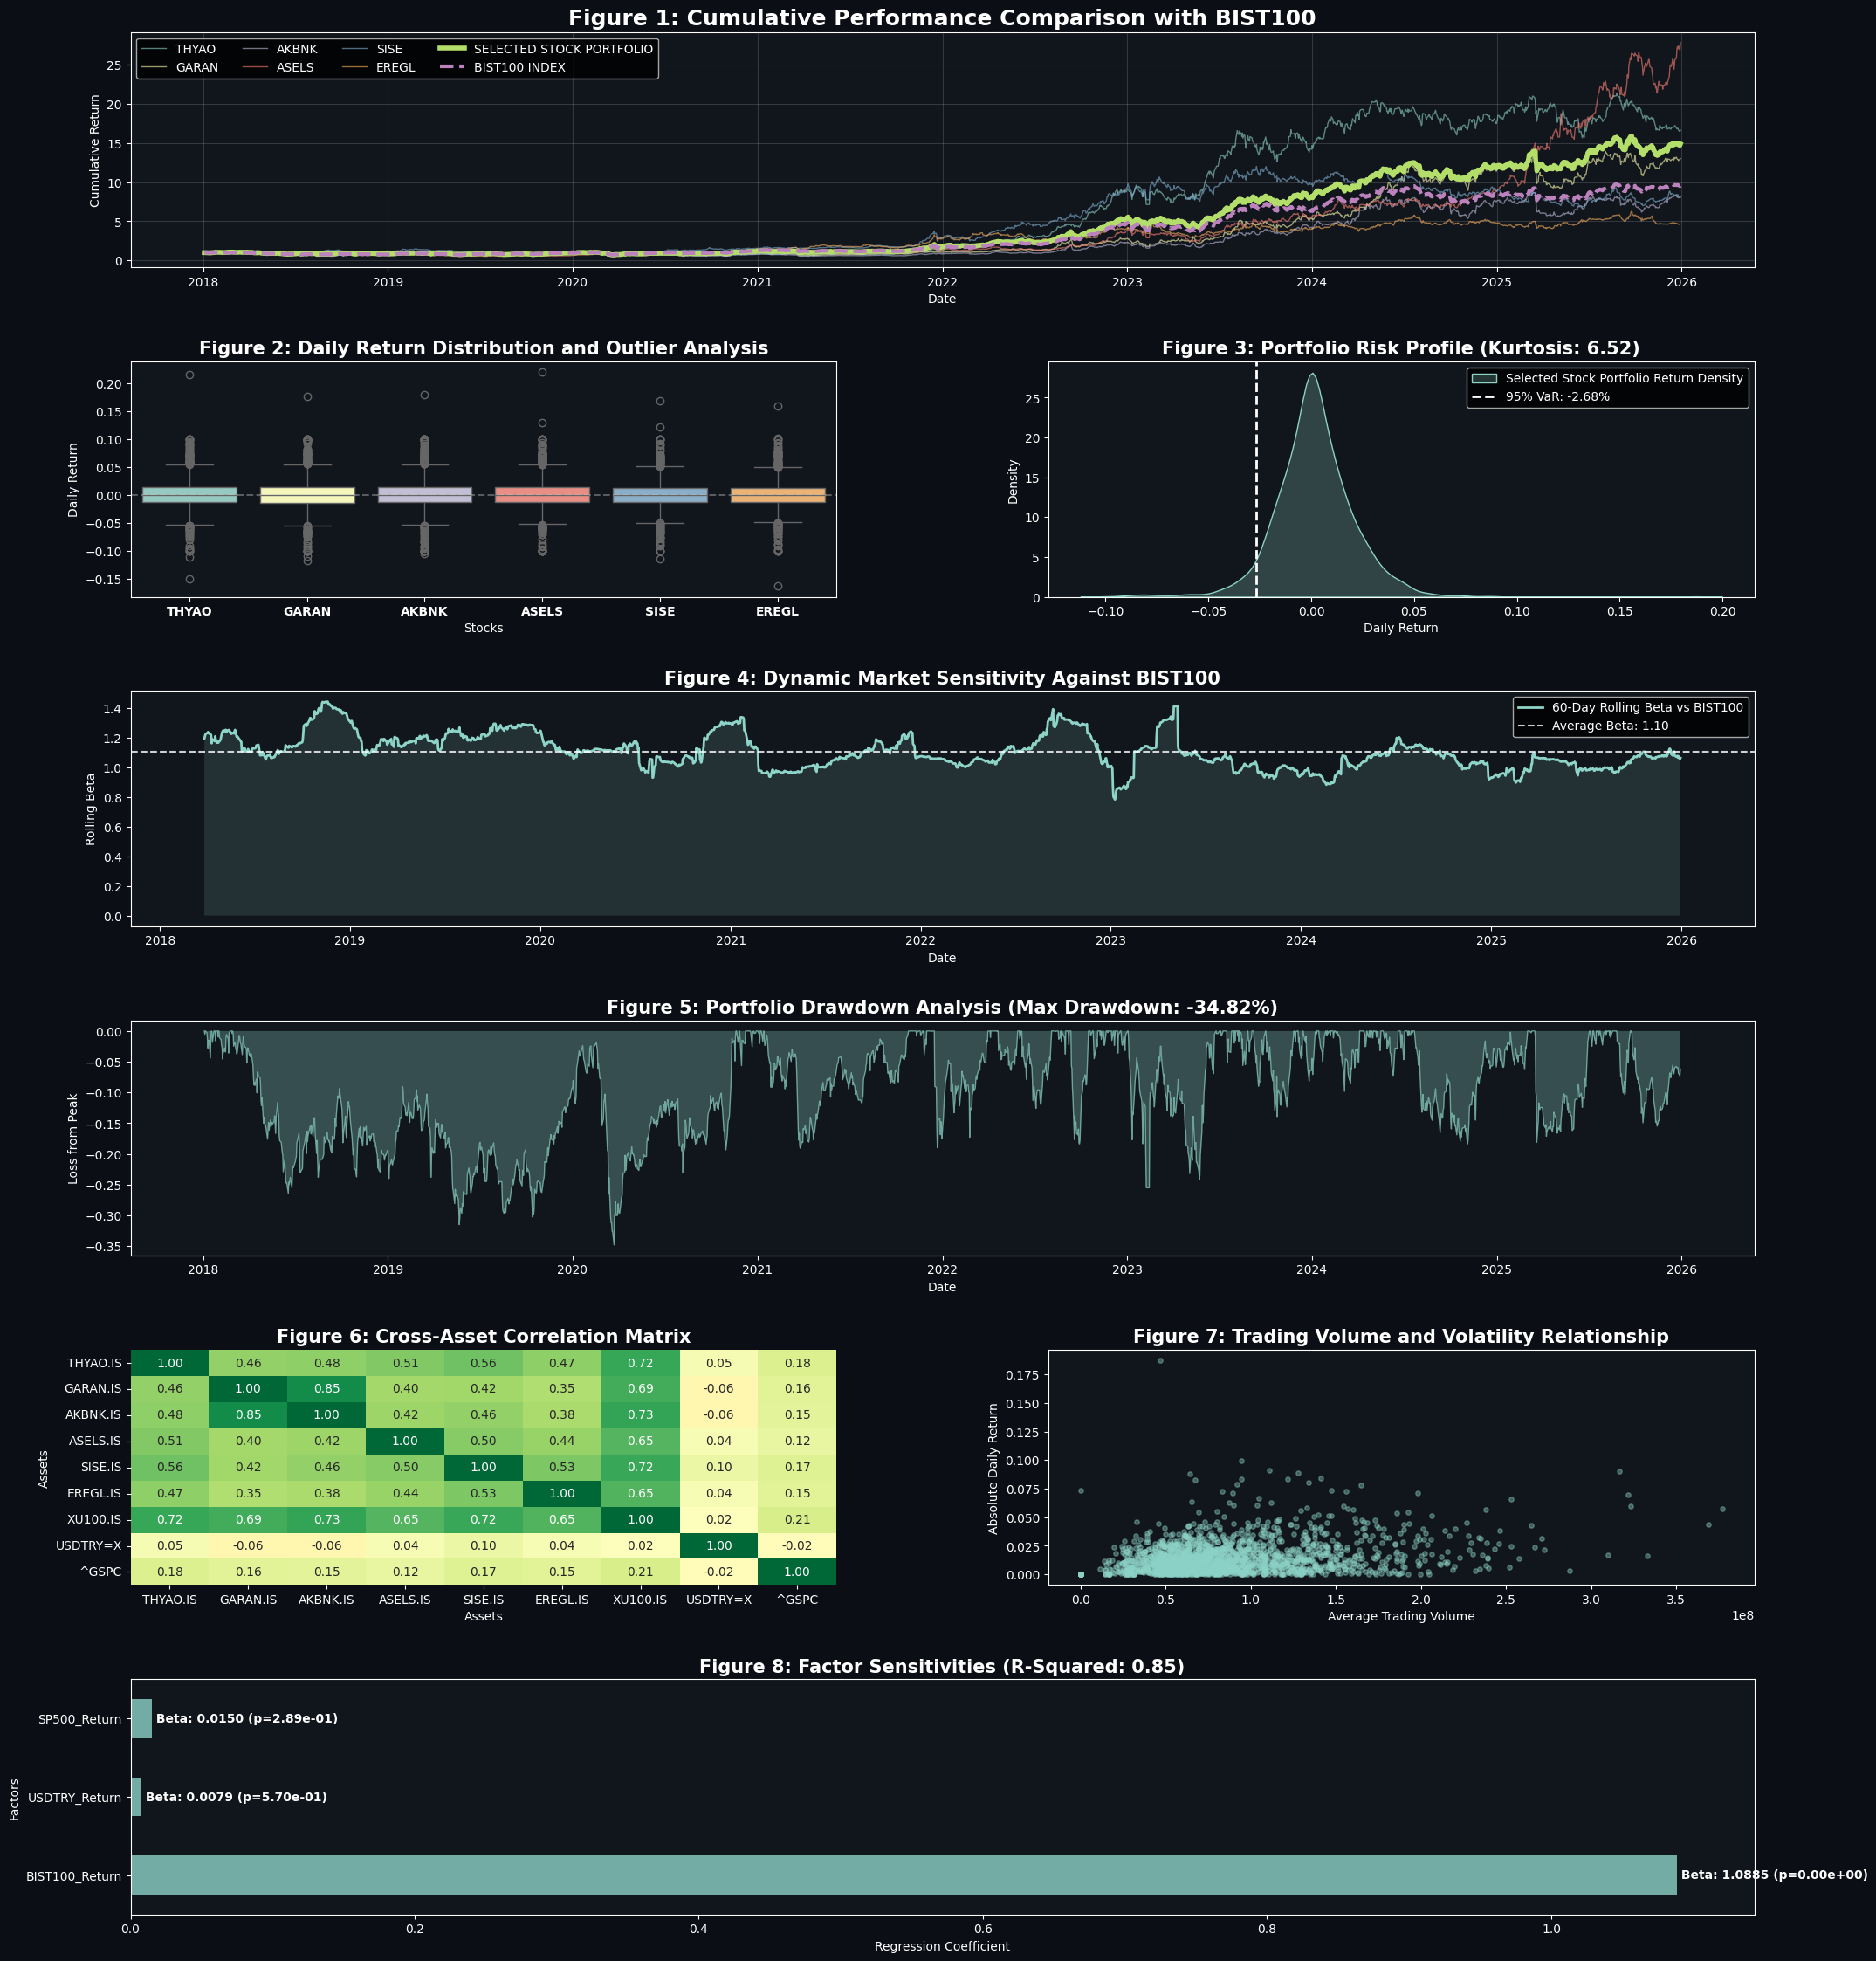


HYPOTHESIS TESTING AND STATISTICAL INTERPRETATION

Hypothesis 1: Paired t-Test
H0: There is no statistically significant difference between selected stock portfolio returns and BIST100 returns.
H1: There is a statistically significant difference between selected stock portfolio returns and BIST100 returns.
T-statistic: 1.5650
P-value: 0.117725
Result: Fail to reject H0. The selected stock portfolio does not significantly differ from BIST100.

Hypothesis 2: Pearson Correlation Test
H0: Trading volume and volatility are not significantly related.
H1: Trading volume and volatility are significantly related.
Correlation: 0.2781
P-value: 0.000000
Result: Reject H0. Trading volume and volatility have a statistically significant relationship.

Hypothesis 3: Jarque-Bera Normality Test
H0: Returns are normally distributed.
H1: Returns are not normally distributed.
Statistic: 3681.2596
P-value: 0.000000
Result: Reject H0. Returns are non-normal and heavy-tailed.

Hypothesis 4: Augmented Dickey-

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from matplotlib.gridspec import GridSpec

tickers = ['THYAO.IS', 'GARAN.IS', 'AKBNK.IS', 'ASELS.IS', 'SISE.IS', 'EREGL.IS']
market = 'XU100.IS'
macro = 'USDTRY=X'
world = '^GSPC'

raw_data = yf.download(
    tickers + [market, macro, world],
    start='2018-01-01',
    end='2025-12-31',
    progress=False,
    auto_adjust=False
)

prices = raw_data['Close'].ffill()
volumes = raw_data['Volume'].ffill()

available_cols = [c for c in tickers + [market, macro, world] if c in prices.columns]
data = prices[available_cols].dropna()
returns = data.pct_change().dropna()

stock_ret = returns[tickers]
mkt_ret = returns[market]
fx_ret = returns[macro]
global_ret = returns[world]

# Equal-weighted stock portfolio is only used as the selected stock group.
# BIST100 is used as the actual market benchmark.
selected_stock_ret = stock_ret.mean(axis=1)
bist100_ret = mkt_ret.copy()

var_95 = np.percentile(selected_stock_ret, 5)

cum_stocks = (1 + selected_stock_ret).cumprod()
cum_bist100 = (1 + bist100_ret).cumprod()

rolling_max = cum_stocks.cummax()
drawdown = (cum_stocks - rolling_max) / rolling_max
max_dd = drawdown.min()

window = 60
rolling_beta = selected_stock_ret.rolling(window).cov(bist100_ret) / bist100_ret.rolling(window).var()
rolling_beta = rolling_beta.dropna()

plt.style.use('dark_background')
fig = plt.figure(figsize=(24, 28), facecolor='#0B0E14')
gs = GridSpec(6, 2, figure=fig, hspace=0.40, wspace=0.30)

ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#11151C')

for t in tickers:
    ax1.plot((1 + stock_ret[t]).cumprod(), label=t.split('.')[0], alpha=0.6, lw=1)

ax1.plot(cum_stocks, lw=4, label='SELECTED STOCK PORTFOLIO')
ax1.plot(cum_bist100, lw=3, ls='--', label='BIST100 INDEX')
ax1.set_title("Figure 1: Cumulative Performance Comparison with BIST100", fontsize=18, fontweight='bold')
ax1.set_xlabel("Date")
ax1.set_ylabel("Cumulative Return")
ax1.legend(loc='upper left', ncol=4)
ax1.grid(alpha=0.15)

ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#11151C')

sns.boxplot(data=stock_ret, ax=ax2)
ax2.set_xticklabels([t.split('.')[0] for t in tickers], rotation=0, fontweight='bold')
ax2.set_title("Figure 2: Daily Return Distribution and Outlier Analysis", fontsize=15, fontweight='bold')
ax2.set_xlabel("Stocks")
ax2.set_ylabel("Daily Return")
ax2.axhline(0, color='white', ls='--', alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#11151C')

sns.kdeplot(selected_stock_ret, fill=True, ax=ax3, label='Selected Stock Portfolio Return Density')
ax3.axvline(var_95, ls='--', lw=2, label=f'95% VaR: {var_95:.2%}')
ax3.set_title(f"Figure 3: Portfolio Risk Profile (Kurtosis: {selected_stock_ret.kurt():.2f})", fontsize=15, fontweight='bold')
ax3.set_xlabel("Daily Return")
ax3.set_ylabel("Density")
ax3.legend()

ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor('#11151C')

ax4.fill_between(rolling_beta.index, rolling_beta.values, alpha=0.15)
ax4.plot(rolling_beta.index, rolling_beta.values, lw=2, label='60-Day Rolling Beta vs BIST100')
ax4.axhline(rolling_beta.mean(), color='white', ls='--', alpha=0.8, label=f'Average Beta: {rolling_beta.mean():.2f}')
ax4.set_title("Figure 4: Dynamic Market Sensitivity Against BIST100", fontsize=15, fontweight='bold')
ax4.set_xlabel("Date")
ax4.set_ylabel("Rolling Beta")
ax4.legend()

ax5 = fig.add_subplot(gs[3, :])
ax5.set_facecolor('#11151C')

ax5.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3)
ax5.plot(drawdown.index, drawdown.values, lw=1, alpha=0.7)
ax5.set_title(f"Figure 5: Portfolio Drawdown Analysis (Max Drawdown: {max_dd:.2%})", fontsize=15, fontweight='bold')
ax5.set_xlabel("Date")
ax5.set_ylabel("Loss from Peak")

ax6 = fig.add_subplot(gs[4, 0])

full_corr = pd.concat([stock_ret, bist100_ret, fx_ret, global_ret], axis=1).corr()
sns.heatmap(full_corr, annot=True, cmap='RdYlGn', fmt='.2f', ax=ax6, cbar=False, center=0)
ax6.set_title("Figure 6: Cross-Asset Correlation Matrix", fontsize=15, fontweight='bold')
ax6.set_xlabel("Assets")
ax6.set_ylabel("Assets")

ax7 = fig.add_subplot(gs[4, 1])
ax7.set_facecolor('#11151C')

avg_volume = volumes[tickers].mean(axis=1)

scatter_data = pd.DataFrame({
    'Average Volume': avg_volume,
    'Absolute Return': selected_stock_ret.abs()
}).dropna()

ax7.scatter(scatter_data['Average Volume'], scatter_data['Absolute Return'], alpha=0.4, s=15)
ax7.set_title("Figure 7: Trading Volume and Volatility Relationship", fontsize=15, fontweight='bold')
ax7.set_xlabel("Average Trading Volume")
ax7.set_ylabel("Absolute Daily Return")

ax8 = fig.add_subplot(gs[5, :])
ax8.set_facecolor('#11151C')

X = pd.concat([bist100_ret, fx_ret, global_ret], axis=1).dropna()
X.columns = ['BIST100_Return', 'USDTRY_Return', 'SP500_Return']
X = sm.add_constant(X)

y = selected_stock_ret.loc[X.index]

reg_model = sm.OLS(y, X).fit()

reg_model.params[1:].plot(kind='barh', ax=ax8, alpha=0.8)
ax8.set_title(f"Figure 8: Factor Sensitivities (R-Squared: {reg_model.rsquared:.2f})", fontsize=15, fontweight='bold')
ax8.set_xlabel("Regression Coefficient")
ax8.set_ylabel("Factors")

for i, v in enumerate(reg_model.params[1:]):
    ax8.text(v, i, f' Beta: {v:.4f} (p={reg_model.pvalues.iloc[i+1]:.2e})',
             va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("HYPOTHESIS TESTING AND STATISTICAL INTERPRETATION")
print("="*80)

print("\nHypothesis 1: Paired t-Test")
print("H0: There is no statistically significant difference between selected stock portfolio returns and BIST100 returns.")
print("H1: There is a statistically significant difference between selected stock portfolio returns and BIST100 returns.")

paired_test = stats.ttest_rel(
    selected_stock_ret.loc[bist100_ret.index],
    bist100_ret.loc[selected_stock_ret.index]
)

print(f"T-statistic: {paired_test.statistic:.4f}")
print(f"P-value: {paired_test.pvalue:.6f}")

if paired_test.pvalue < 0.05:
    print("Result: Reject H0. The selected stock portfolio returns are statistically different from BIST100 returns.")
else:
    print("Result: Fail to reject H0. The selected stock portfolio does not significantly differ from BIST100.")

print("\nHypothesis 2: Pearson Correlation Test")
print("H0: Trading volume and volatility are not significantly related.")
print("H1: Trading volume and volatility are significantly related.")

corr_test = stats.pearsonr(scatter_data['Average Volume'], scatter_data['Absolute Return'])

print(f"Correlation: {corr_test[0]:.4f}")
print(f"P-value: {corr_test[1]:.6f}")

if corr_test[1] < 0.05:
    print("Result: Reject H0. Trading volume and volatility have a statistically significant relationship.")
else:
    print("Result: Fail to reject H0. No statistically significant relationship is found.")

print("\nHypothesis 3: Jarque-Bera Normality Test")
print("H0: Returns are normally distributed.")
print("H1: Returns are not normally distributed.")

jb_test = stats.jarque_bera(selected_stock_ret.dropna())

print(f"Statistic: {jb_test.statistic:.4f}")
print(f"P-value: {jb_test.pvalue:.6f}")

if jb_test.pvalue < 0.05:
    print("Result: Reject H0. Returns are non-normal and heavy-tailed.")
else:
    print("Result: Fail to reject H0. Returns do not significantly deviate from normality.")

print("\nHypothesis 4: Augmented Dickey-Fuller Stationarity Test")
print("H0: Return series is non-stationary.")
print("H1: Return series is stationary.")

adf_test = adfuller(selected_stock_ret.dropna())

print(f"ADF Statistic: {adf_test[0]:.4f}")
print(f"P-value: {adf_test[1]:.6f}")

if adf_test[1] < 0.05:
    print("Result: Reject H0. Return series is stationary.")
else:
    print("Result: Fail to reject H0. Return series may be non-stationary.")

print("\nRegression Summary:")
print(reg_model.summary())

print("\n" + "="*80)
print("ACADEMIC SUMMARY STATISTICS")
print("="*80)
print(f"Mean Rolling Beta vs BIST100: {rolling_beta.mean():.4f}")
print(f"95% VaR: {var_95:.4%}")
print(f"Maximum Drawdown: {max_dd:.4%}")
print(f"Portfolio Kurtosis: {selected_stock_ret.kurt():.4f}")
print("="*80)